In [1]:
!pip install google-play-scraper pandas nltk Sastrawi scikit-learn matplotlib seaborn


  Using cached Sastrawi-1.0.1-py2.py3-none-any.whl (209 kB)
  Using cached scikit_learn-1.8.0-cp311-cp311-win_amd64.whl (8.1 MB)
  Using cached scipy-1.17.1-cp311-cp311-win_amd64.whl (36.6 MB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)



[notice] A new release of pip available: 22.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


1. Scraping Review TIX ID App

In [2]:
from google_play_scraper import reviews_all, Sort
import pandas as pd

tix_reviews = reviews_all(
    'id.tix.android',
    lang='id',
    country='id',
    sort=Sort.NEWEST
)

df = pd.DataFrame(tix_reviews)
df = df[['content', 'score', 'at']]
df = df.dropna(subset=['content'])

df = df[df['content'].str.strip() != '']

print(f'Total Review: {len(df)}')
df.head()

Total Review: 96289


,content,score,at
0,saya beli tiket sudah bayar pakai qris dari qr...,1,2026-05-02 20:33:20
1,hallo apakah ada email yg bisa langsung di kon...,2,2026-05-02 15:09:24
2,"membantu sekali, kalo bisa banyakin promo",5,2026-05-02 07:18:06
3,knp aplekasi ini gk bisa di buka,5,2026-04-30 09:23:36
4,bagus banget,5,2026-04-27 18:12:22


2. Label Sentiment

In [3]:
def label_sentiment(score: int) -> str:
    if score >= 4:
        return 'Positive'
    elif score == 3:
        return 'Neutral'
    else:
        return 'Negative'

df['sentiment'] = df['score'].apply(label_sentiment)

3. Regex (Text Cleaning)

In [4]:
import re

def clean_text(text: str) -> str:
    text = text.lower()
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    text = re.sub(r'(.)\1{2,}', r'\1', text)  # huruf berulang
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['clean_content'] = df['content'].apply(clean_text)


4. Stopword Removal

In [5]:
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')

stop = stopwords.words('indonesian')

df['no_stopwords'] = df['clean_content'].apply(
    lambda x: ' '.join([word for word in x.split() if word not in stop])
)

[nltk_data] Downloading package stopwords to C:\Users\Ratna
[nltk_data]     Amalia\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


5. Stemming

In [6]:
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

factory = StemmerFactory()
stemmer = factory.create_stemmer()

df['stemmed'] = df['no_stopwords'].apply(stemmer.stem)

6. Bag of Words

In [7]:
from sklearn.feature_extraction.text import CountVectorizer

# ambil 50 data
df_sample = df.sample(50, random_state=42)

bow_vectorizer = CountVectorizer(max_features=20)

X_bow = bow_vectorizer.fit_transform(df_sample['stemmed'])

bow_df = pd.DataFrame(
    X_bow.toarray(),
    columns=bow_vectorizer.get_feature_names_out()
)

print("=== BoW Matrix ===")
print(bow_df.head())

print("\nShape:", bow_df.shape)

=== BoW Matrix ===
   antri  aplikasi  bagus  bantu  beli  bioskop  cape  ga  gimana  good  id  \
0      0         0      0      0     0        0     0   1       0     0   0   
1      0         0      0      0     0        0     0   0       0     1   0   
2      1         0      0      0     0        1     0   0       0     0   1   
3      0         0      0      0     0        0     0   0       0     0   0   
4      0         0      0      0     0        0     0   0       0     0   0   

   kode  mantap  mudah  nonton  pakai  tiket  tix  utk  voucher  
0     0       0      0       0      0      0    0    0        0  
1     0       0      0       0      0      0    0    0        0  
2     1       0      0       1      0      0    1    0        1  
3     0       0      0       0      0      0    0    0        0  
4     0       0      0       0      0      0    0    0        0  

Shape: (50, 20)


6a. Split Data

In [8]:
df_pos = df[df['sentiment'] == 'Positive'].sample(50, random_state=42)
df_neg = df[df['sentiment'] == 'Negative'].sample(50, random_state=42)

6b. BoW Positive & Negative

In [9]:
vectorizer_pos = CountVectorizer(max_features=20)
X_pos = vectorizer_pos.fit_transform(df_pos['stemmed'])

bow_pos = pd.DataFrame(
    X_pos.toarray(),
    columns=vectorizer_pos.get_feature_names_out()
)

print("=== BoW Positive ===")
print(bow_pos.head())

vectorizer_neg = CountVectorizer(max_features=20)
X_neg = vectorizer_neg.fit_transform(df_neg['stemmed'])

bow_neg = pd.DataFrame(
    X_neg.toarray(),
    columns=vectorizer_neg.get_feature_names_out()
)

print("\n=== BoW Negative ===")
print(bow_neg.head())

=== BoW Positive ===
   aplikasi  bagus  baguss  banget  bantu  beli  dana  good  id  keren  kode  \
0         0      0       0       0      1     0     0     0   0      0     0   
1         0      0       0       0      0     0     0     0   0      0     0   
2         0      0       0       0      0     1     0     0   0      0     0   
3         0      0       0       0      0     0     0     0   0      0     0   
4         1      0       0       0      0     0     0     0   0      1     0   

   mantap  mudah  ngantri  ok  rp  sip  tiket  tix  tolong  
0       0      0        0   0   0    0      0    0       0  
1       0      0        0   0   0    0      0    0       0  
2       1      1        0   0   0    0      1    0       0  
3       0      0        0   0   0    0      0    0       0  
4       0      0        0   0   0    0      0    0       0  

=== BoW Negative ===
   aja  aplikasi  baik  banget  beli  buka  daftar  ga  gagal  gak  kode  \
0    0         0     1       0    

7. Analisis BoW

In [10]:
word_freq = bow_df.sum().sort_values(ascending=False)

print("\n=== Top Words ===")
print(word_freq.head(10))

pos_words = bow_pos.sum().sort_values(ascending=False)
neg_words = bow_neg.sum().sort_values(ascending=False)

print("\n=== Top Positive Words ===")
print(pos_words.head(10))

print("\n=== Top Negative Words ===")
print(neg_words.head(10))


=== Top Words ===
tiket       8
bantu       6
good        6
bagus       6
tix         6
nonton      5
mantap      4
aplikasi    4
id          4
bioskop     4
dtype: int64

=== Top Positive Words ===
keren       8
good        6
mudah       5
tiket       5
bantu       4
ok          4
bagus       4
aplikasi    4
tolong      3
tix         3
dtype: int64

=== Top Negative Words ===
ga          19
tiket       15
gak         13
aplikasi    10
buka        10
daftar      10
nya          9
kota         9
kode         8
beli         8
dtype: int64


8. Regex Insight

In [11]:
issue_patterns = {
    'login_issue': r'login|masuk|signin',
    'payment_issue': r'bayar|pembayaran|gagal bayar',
    'app_crash': r'error|crash|force close|bug',
    'slow_app': r'lambat|lemot|loading lama',
    'ticket_issue': r'tiket|kursi|booking'
}

def detect_issues(text: str):
    found = []
    for issue, pattern in issue_patterns.items():
        if re.search(pattern, text):
            found.append(issue)
    return found

df['issues'] = df['clean_content'].apply(detect_issues)

9. Analisis Regex

In [12]:
from collections import Counter

all_issues = sum(df['issues'], [])
issue_counts = Counter(all_issues)

print("\n=== Issue Counts ===")
print(issue_counts)


=== Issue Counts ===
Counter({'ticket_issue': 10523, 'login_issue': 3041, 'payment_issue': 2077, 'app_crash': 675, 'slow_app': 578})


10. Visualisasi

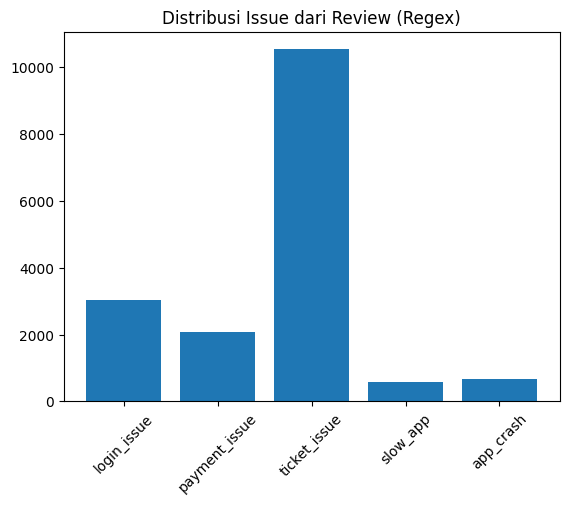

In [13]:
import matplotlib.pyplot as plt

plt.figure()
plt.bar(issue_counts.keys(), issue_counts.values())
plt.title("Distribusi Issue dari Review (Regex)")
plt.xticks(rotation=45)
plt.show()